In [ ]:
## Instalar paquetes

In [39]:
pip install shap



   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [21]:
pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 613.7 kB/s eta 0:01:53
   ---------------------------------------- 0.5/69.5 MB 613.7 kB/s eta 0:01:53
   ---------------------------------------- 0.8/69.5 MB 646.3 kB/s eta 0:01:47
    --------------------------------------- 1.0/69.5 MB 724.3 kB/s eta 0:01:35
    --------------------------------------- 1.0/69.5 M

Librerías a usar

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier

**1.- PREPROCESAMIENTO** 

In [48]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

In [25]:
# Configuración estética para los gráficos 
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

In [5]:
# 1. CARGA DEL DATASET
# Usamos el archivo de Kaggle de Alex Teboul (BRFSS 2015)
df = pd.read_csv("base_diabetes.csv")

In [7]:
print("--- 1. PRIMER VISTAZO A LOS DATOS ---")
print(f"Cantidad total de registros (Filas): {df.shape[0]:,}")
print(f"Cantidad de variables analizadas (Columnas): {df.shape[1]}")

print("\n--- 2. VERIFICACIÓN DE CALIDAD DE DATOS (NULOS Y TIPOS) ---")
# Esto demuestra que controlamos la calidad antes de modelar
info_datos = pd.DataFrame({
    'Tipo de Dato': df.dtypes,
    'Valores Nulos': df.isnull().sum(),
    'Valores Únicos': df.nunique()
})
print(info_datos)

--- 1. PRIMER VISTAZO A LOS DATOS ---
Cantidad total de registros (Filas): 253,680
Cantidad de variables analizadas (Columnas): 22

--- 2. VERIFICACIÓN DE CALIDAD DE DATOS (NULOS Y TIPOS) ---
                     Tipo de Dato  Valores Nulos  Valores Únicos
Diabetes_012              float64              0               3
HighBP                    float64              0               2
HighChol                  float64              0               2
CholCheck                 float64              0               2
BMI                       float64              0              84
Smoker                    float64              0               2
Stroke                    float64              0               2
HeartDiseaseorAttack      float64              0               2
PhysActivity              float64              0               2
Fruits                    float64              0               2
Veggies                   float64              0               2
HvyAlcoholConsump         fl

In [6]:
df.head(5)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [10]:
print("\n--- 2. ANÁLISIS DE LA VARIABLE OBJETIVO MULTICLASE (Diabetes_012) ---")
conteo_clases = df['Diabetes_012'].value_counts()
porcentaje_clases = df['Diabetes_012'].value_counts(normalize=True) * 100

df_target = pd.DataFrame({
    'Significado': ['No Diabetes (0)', 'Diabetes (2)', 'Prediabetes (1)'], # Reordenado según el conteo real
    'Casos de la muestra': conteo_clases,
    'Porcentaje (%)': porcentaje_clases
})
print(df_target.to_string())


--- 2. ANÁLISIS DE LA VARIABLE OBJETIVO MULTICLASE (Diabetes_012) ---
                  Significado  Casos de la muestra  Porcentaje (%)
Diabetes_012                                                      
0.0           No Diabetes (0)               213703       84.241170
2.0              Diabetes (2)                35346       13.933302
1.0           Prediabetes (1)                 4631        1.825528


C:\Users\DELL\AppData\Local\Temp\ipykernel_29388\640566774.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df_target['Significado'], y=df_target['Casos de la muestra'], palette='viridis')


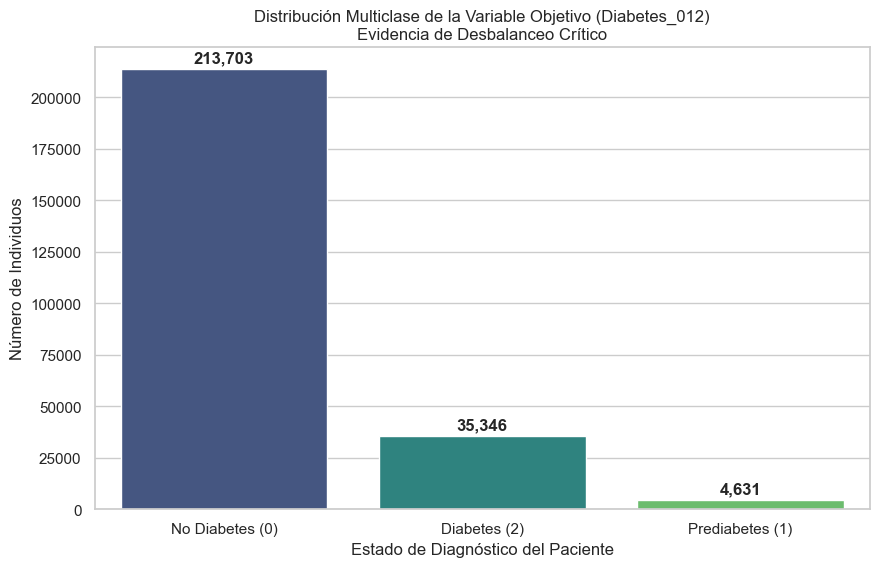

In [11]:
# Gráfico 1: Desbalanceo real en problemas de salud multiclase
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=df_target['Significado'], y=df_target['Casos de la muestra'], palette='viridis')
plt.title('Distribución Multiclase de la Variable Objetivo (Diabetes_012)\nEvidencia de Desbalanceo Crítico')
plt.ylabel('Número de Individuos')
plt.xlabel('Estado de Diagnóstico del Paciente')
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', weight='bold')
plt.savefig('51_distribucion_clases.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
print("\n--- 3. ANÁLISIS DESCRIPTIVO DE VARIABLES CONTINUAS CRÍTICAS ---")
# BMI (IMC), MentHlth (Salud Mental en días), PhysHlth (Salud Física en días)
variables_continuas = ['BMI', 'MentHlth', 'PhysHlth']
print(df.groupby('Diabetes_012')[variables_continuas].mean().round(2))


--- 3. ANÁLISIS DESCRIPTIVO DE VARIABLES CONTINUAS CRÍTICAS ---
                BMI  MentHlth  PhysHlth
Diabetes_012                           
0.0           27.74      2.94      3.58
1.0           30.72      4.53      6.35
2.0           31.94      4.46      7.95


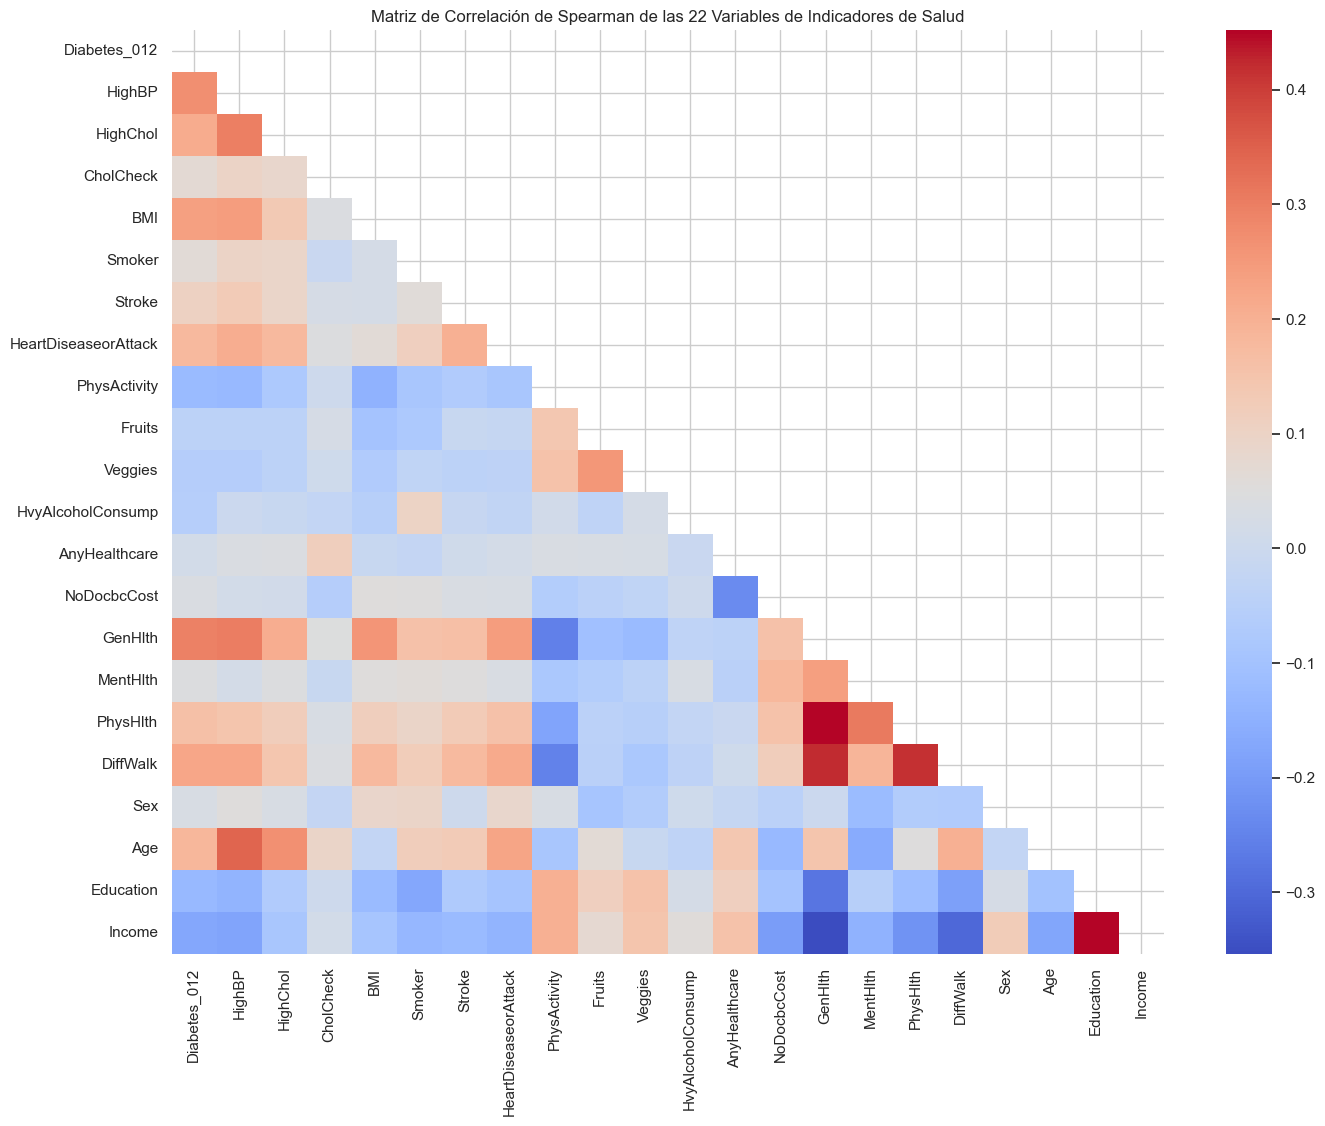

In [17]:
# Gráfico 2: Matriz de Correlación Térmica (Heatmap) para Selección de Características
plt.figure(figsize=(16, 12))
# Calculamos correlación de Spearman porque la mayoría son variables categóricas u ordinales
corr = df.corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool)) # Máscara para ver solo la mitad inferior


sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', fmt=".2f")

plt.title('Matriz de Correlación de Spearman de las 22 Variables de Indicadores de Salud')
plt.savefig('51_matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
print("\n--- 4. COMPROBACIÓN ÉTICA Y CALIDAD (VALORES NULOS) ---")
print(f"Valores nulos totales en el dataset: {df.isnull().sum().sum()}")


--- 4. COMPROBACIÓN ÉTICA Y CALIDAD (VALORES NULOS) ---
Valores nulos totales en el dataset: 0


**2.- Entrenamiento comparativo**

In [27]:
# 1. DIVISIÓN EN MATRIZ DE CARACTERÍSTICAS Y VARIABLE OBJETIVO
X = df.drop(columns=['Diabetes_012'])
y = df['Diabetes_012'].astype(int)

In [30]:
# Separación 80% entrenamiento y 20% test estratificado por el desbalanceo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- BALANCEO DE CLASES EN ENTRENAMIENTO ---")
print(y_train.value_counts(normalize=True) * 100)

--- BALANCEO DE CLASES EN ENTRENAMIENTO ---
Diabetes_012
0    84.240973
2    13.933400
1     1.825627
Name: proportion, dtype: float64


In [31]:
#CÁLCULO DE PESOS PARA PONDERAR EL SEVERO DESBALANCEO 
# Obtenemos los pesos inversamente proporcionales a la frecuencia de cada clase
pesos = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
dicc_pesos = {i: peso for i, peso in enumerate(pesos)}
print(f"\nPesos calculados para equilibrar las 3 clases:\n{dicc_pesos}")

# Para XGBoost multiclase, necesitamos mapear los pesos por cada fila del set de entrenamiento
pesos_por_fila = y_train.map(dicc_pesos)


Pesos calculados para equilibrar las 3 clases:
{0: np.float64(0.395690270352476), 1: np.float64(18.258569500674763), 2: np.float64(2.392332991477172)}


**REGRESIÓN LOGÍSTICA**

In [32]:
#ENTRENAMIENTO MULTICLASE (Capítulo 5.2)

print("\n--- 1. Entrenando Regresión Logística Multinomial (Línea Base) ---")
# 'multinomial' activa Softmax. class_weight='balanced' aplica los pesos calculados automáticamente
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)


--- 1. Entrenando Regresión Logística Multinomial (Línea Base) ---


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=1000,
                   multi_class='multinomial', random_state=42)

**XGBoost**

In [33]:
print("\n--- 2. Entrenando XGBoost Multiclase (Ensamble de Árboles) ---")
# multi:softprob devuelve las probabilidades para cada una de las 3 clases
xgb_model = XGBClassifier(objective='multi:softprob', num_class=3, random_state=42, eval_metric='mlogloss')
# Pasamos los pesos a través de sample_weight en el fit
xgb_model.fit(X_train, y_train, sample_weight=pesos_por_fila)


--- 2. Entrenando XGBoost Multiclase (Ensamble de Árboles) ---


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3, ...)

**Redes Neurolanes MLP multiclase**

In [35]:
print("\n--- 3. Entrenando Red Neuronal Artificial (MLP Multiclase) ---")
# La capa de salida usará Softmax automáticamente por tener 3 neuronas de salida
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
mlp_model.fit(X_train, y_train)


--- 3. Entrenando Red Neuronal Artificial (MLP Multiclase) ---


MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)

In [36]:
# EXTRACCIÓN DE MÉTRICAS ADAPTADAS 
modelos = {
    "Regresión Logística (Softmax)": log_reg,
    "XGBoost Multiclase": xgb_model,
    "Red Neuronal (MLP)": mlp_model
}

resultados_multiclase = []

for nombre, modelo in modelos.items():
    preds = modelo.predict(X_test)
    reporte = classification_report(y_test, preds, output_dict=True)
    
    # En multiclase extraemos el Recall macro avg (promedio de las 3 clases) 
    # y el Recall específico de la Prediabetes (clase 1) y Diabetes (clase 2)
    recall_sano = reporte['0']['recall']
    recall_prediabetes = reporte['1']['recall']
    recall_diabetes = reporte['2']['recall']
    accuracy_global = reporte['accuracy']
    kappa = cohen_kappa_score(y_test, preds) # Métrica robusta para desbalanceo
    
    resultados_multiclase.append({
        "Modelo": nombre,
        "Accuracy Global": accuracy_global,
        "Recall Sano (0)": recall_sano,
        "Recall Prediabetes (1)": recall_prediabetes,
        "Recall Diabetes (2)": recall_diabetes,
        "Índice Kappa": kappa
    })

In [37]:
# Convertimos a DataFrame para la visualización
df_res_final = pd.DataFrame(resultados_multiclase)
print("\n### TABLA COMPARATIVA MULTICLASE FINALES ###")
print(df_res_final.to_string(index=False))


### TABLA COMPARATIVA MULTICLASE FINALES ###
                       Modelo  Accuracy Global  Recall Sano (0)  Recall Prediabetes (1)  Recall Diabetes (2)  Índice Kappa
Regresión Logística (Softmax)         0.645794         0.662993                0.326134             0.583675      0.246129
           XGBoost Multiclase         0.645498         0.657027                0.227862             0.630499      0.246003
           Red Neuronal (MLP)         0.848431         0.986406                0.000000             0.125336      0.151683


**3.- explicabilidad_y_validacio**

**Código en Python para generar la Explicabilidad (SHAP)**

In [42]:
# 1. INICIALIZAR EL EXPLICADOR DE SHAP PARA ÁRBOLES (TreeExplainer)
# Usamos tu modelo entrenado xgb_model
explainer = shap.TreeExplainer(xgb_model)

# 2. SELECCIONAR UNA MUESTRA DE PRUEBA PARA AGILIZAR EL CÁLCULO
# Tomamos 1,000 registros al azar de X_test para no saturar CPU
X_sample = X_test.sample(n=1000, random_state=42)

In [43]:
# 3. CALCULAR LOS VALORES SHAP
# Al ser un problema multiclase, shap_values será una lista con 3 matrices (una por clase)
shap_values = explainer.shap_values(X_sample)

print("--- VALORES SHAP CALCULADOS CON ÉXITO ---")

--- VALORES SHAP CALCULADOS CON ÉXITO ---


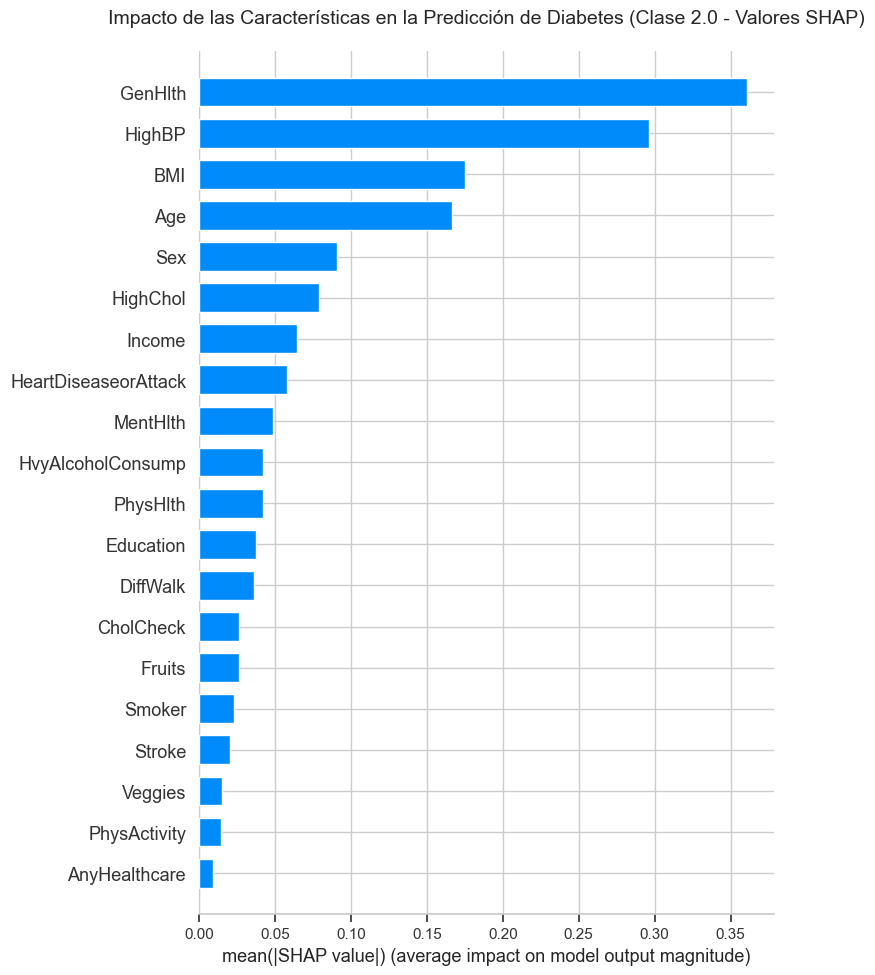

In [47]:
# shap_values[2] representa el impacto de las variables para la clase 2.0 (Diabetes)

# 4. GENERAR EL GRÁFICO DE IMPORTANCIA GLOBAL CORREGIDO
plt.figure(figsize=(12, 8))

# CORRECCIÓN: Filtramos explícitamente la matriz de la clase 2 (Diabetes) 
# y nos aseguramos de que los nombres de las columnas coincidan perfectamente.
# Alternativa si el formato multiclase viene indexado de forma nativa por la librería:
shap.summary_plot(shap_values[:, :, 2], X_sample, plot_type="bar", show=False)

plt.title("Impacto de las Características en la Predicción de Diabetes (Clase 2.0 - Valores SHAP)", fontsize=14, pad=20)
plt.savefig('55_shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

**Validación**

In [49]:
# 1. CONFIGURAMOS LA VALIDACIÓN CRUZADA ESTRATIFICADA CON 5 BLOQUES
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- Ejecutando Validación Cruzada Estratificada (K=5) ---")

# Calculamos el Accuracy en los 5 bloques para XGBoost
scores_accuracy = cross_val_score(xgb_model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

print(f"Resultados de Accuracy por bloque: {scores_accuracy}")
print(f"Accuracy Promedio: {np.mean(scores_accuracy):.6f}")
print(f"Desviación Estándar: {np.std(scores_accuracy):.6f}")

--- Ejecutando Validación Cruzada Estratificada (K=5) ---
Resultados de Accuracy por bloque: [0.84977137 0.84860848 0.85008672 0.84839167 0.84758357]
Accuracy Promedio: 0.848888
Desviación Estándar: 0.000921
